<a href="https://colab.research.google.com/github/Himadri-Das68/AI-Powered-Real-Time-ECG-Signal-Diagnostic-System-Using-Signal-Processing-and-Deep-Learning/blob/main/ECG_monitor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 42.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.


In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

In [ ]:
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

signal = record.p_signal[:,0]
peaks = annotation.sample
labels = annotation.symbol

In [ ]:
def bandpass_filter(signal):
    b, a = butter(2, [0.5/180, 40/180], btype='band')
    return filtfilt(b, a, signal)

filtered_signal = bandpass_filter(signal)

In [ ]:
def extract_beats(signal, peaks, size=200):
    beats = []
    for p in peaks:
        if p-size//2 >= 0 and p+size//2 < len(signal):
            beats.append(signal[p-size//2:p+size//2])
    return np.array(beats)

beats = extract_beats(filtered_signal, peaks)

In [ ]:
def label_map(l):
    return 0 if l == 'N' else 1

y = np.array([label_map(l) for l in labels[:len(beats)]])
X = beats

In [ ]:
from sklearn.utils import resample

# Separate normal and abnormal
normal_X = X[y == 0]
abnormal_X = X[y == 1]

normal_y = y[y == 0]
abnormal_y = y[y == 1]

print("Before balancing:")
print("Normal:", len(normal_X))
print("Abnormal:", len(abnormal_X))

# Upsample abnormal class
abnormal_X_upsampled = resample(
    abnormal_X,
    replace=True,
    n_samples=len(normal_X),
    random_state=42
)

abnormal_y_upsampled = np.ones(len(normal_X))

# Combine balanced data
X_balanced = np.concatenate([normal_X, abnormal_X_upsampled])
y_balanced = np.concatenate([normal_y, abnormal_y_upsampled])

print("\nAfter balancing:")
print("Total samples:", len(X_balanced))
print("Normal:", sum(y_balanced == 0))
print("Abnormal:", sum(y_balanced == 1))

Before balancing:
Normal: 2236
Abnormal: 35

After balancing:
Total samples: 4472
Normal: 2236
Abnormal: 2236


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

X = X[..., np.newaxis]

model = Sequential([
    Conv1D(16, 3, activation='relu', input_shape=(200,1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_balanced, y_balanced, epochs=5)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5454 - loss: 0.6851
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6205 - loss: 0.6508
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6771 - loss: 0.6065
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7136 - loss: 0.5698
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7346 - loss: 0.5368


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


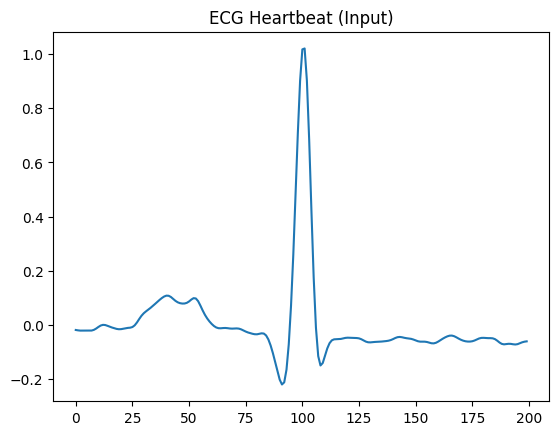

Prediction: Normal


In [ ]:
# pick one heartbeat
sample = X[10]

# predict
pred = model.predict(sample[np.newaxis, ...])

# show graph
plt.plot(sample)
plt.title("ECG Heartbeat (Input)")
plt.show()

# show result
if pred[0][0] > 0.5:
    print("Prediction: Abnormal")
else:
    print("Prediction: Normal")

In [ ]:
for i in range(10):
    sample = X_balanced[i]
    pred = model.predict(sample[np.newaxis, ...])

    result = "Abnormal" if pred[0][0] > 0.5 else "Normal"
    print(f"Sample {i}: {result}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Sample 0: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Sample 1: Abnormal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Sample 2: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Sample 3: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Sample 4: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Sample 5: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Sample 6: Abnormal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Sample 7: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Sample 8: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Sample 9: Abnormal


To get a better understanding of the model's performance, let's split the balanced dataset into training and test sets and then evaluate the model using a classification report and confusion matrix.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Split the balanced data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")


Training samples: 3577
Test samples: 895


In [ ]:
from sklearn.utils import class_weight

# Calculate class weights for imbalanced dataset
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("Calculated Class Weights:", class_weights_dict)

Calculated Class Weights: {0: np.float64(1.0070382882882882), 1: np.float64(0.99305941143809)}


In [ ]:
model.fit(X_train, y_train, epochs=10, verbose=0, class_weight=class_weights_dict) # Train for more epochs with class weights

# Make predictions on the test set
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

print("Classification Report (with class weights):")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix (with class weights):")
print(confusion_matrix(y_test, y_pred))


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report (with class weights):
              precision    recall  f1-score   support

         0.0       0.95      0.82      0.88       460
         1.0       0.83      0.96      0.89       435

    accuracy                           0.88       895
   macro avg       0.89      0.89      0.88       895
weighted avg       0.89      0.88      0.88       895


Confusion Matrix (with class weights):
[[375  85]
 [ 18 417]]


To get a completely new validation set, let's perform a new split of the data into training, validation, and test sets. We'll then retrain the model on the new training set and evaluate it on the validation set.

In [ ]:
from sklearn.model_selection import train_test_split

# First, split the balanced data into training + validation, and test sets
X_train_val, X_test_final, y_train_val, y_test_final = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# Then, split the training + validation set into training and validation sets
X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42) # 0.25 of 0.8 is 0.2

print(f"New Training samples: {len(X_train_new)}")
print(f"New Validation samples: {len(X_val_new)}")
print(f"New Final Test samples: {len(X_test_final)}")

New Training samples: 2682
New Validation samples: 895
New Final Test samples: 895


In [ ]:
from sklearn.utils import class_weight

# Calculate class weights for the new training set
class_weights_new = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_new),
    y=y_train_new
)

class_weights_dict_new = dict(enumerate(class_weights_new))
print("Calculated Class Weights for new training set:", class_weights_dict_new)

Calculated Class Weights for new training set: {0: np.float64(0.9962852897473997), 1: np.float64(1.0037425149700598)}


In [ ]:
# Re-initialize the model to ensure a fresh start for training
model_new = Sequential([
    Conv1D(16, 3, activation='relu', input_shape=(200,1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_new.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the new model on the new training set with class weights
print("Training model on new training set...")
model_new.fit(X_train_new, y_train_new, epochs=10, verbose=1, class_weight=class_weights_dict_new)


Training model on new training set...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5332 - loss: 0.6914
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5727 - loss: 0.6824
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6040 - loss: 0.6690
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6312 - loss: 0.6472
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6551 - loss: 0.6230
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6469 - loss: 0.6123
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6786 - loss: 0.5867
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7047 - loss: 0.5685
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7293 - loss: 0.5453
Epoch 10/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7334 - loss: 0.5348


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions on the new validation set
y_val_pred_proba = model_new.predict(X_val_new)
y_val_pred = (y_val_pred_proba > 0.5).astype(int)

print("\nClassification Report on NEW Validation Set:")
print(classification_report(y_val_new, y_val_pred))

print("\nConfusion Matrix on NEW Validation Set:")
print(confusion_matrix(y_val_new, y_val_pred))

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Classification Report on NEW Validation Set:
              precision    recall  f1-score   support

         0.0       0.80      0.68      0.73       430
         1.0       0.74      0.84      0.78       465

    accuracy                           0.76       895
   macro avg       0.77      0.76      0.76       895
weighted avg       0.77      0.76      0.76       895


Confusion Matrix on NEW Validation Set:
[[291 139]
 [ 75 390]]


### Hyperparameter Tuning to Improve Validation Accuracy

To further improve the model's performance and generalization, we can tune its hyperparameters. This involves searching for the optimal combination of parameters that yield the best results on the validation set. We'll use `Keras Tuner` for this process.

First, we need to install the library.

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 988.0 kB/s eta 0:00:00


In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.4 MB/s eta 0:00:00


Now, let's define a function that builds our CNN model. This function will take a `hp` (hyperparameter) object as input, allowing Keras Tuner to try different hyperparameter values.

In [ ]:
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam

def build_tune_model(hp):
    model = Sequential([
        Conv1D(
            filters=hp.Int('conv_1_filters', min_value=16, max_value=64, step=16),
            kernel_size=hp.Choice('conv_1_kernel', values=[3, 5]),
            activation='relu',
            input_shape=(200,1)
        ),
        MaxPooling1D(2),
        Flatten(),
        Dense(
            units=hp.Int('dense_1_units', min_value=10, max_value=64, step=16),
            activation='relu'
        ),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

We'll use a `RandomSearch` tuner to search for the best hyperparameters. We'll specify the `objective` to maximize validation accuracy and limit the number of trials and epochs per trial.

In [ ]:
tuner = kt.RandomSearch(
    build_tune_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir',
    project_name='ecg_tuning'
)

print(tuner.search_space_summary())

# Run the hyperparameter search
tuner.search(
    X_train_new, y_train_new,
    epochs=10,
    validation_data=(X_val_new, y_val_new),
    class_weight=class_weights_dict_new
)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nOptimal hyperparameters: {best_hps.values}")

# Build the best model and evaluate it
best_model = tuner.get_best_models(num_models=1)[0]

print("\nEvaluating best model on the new validation set:")
y_val_pred_proba_tuned = best_model.predict(X_val_new)
y_val_pred_tuned = (y_val_pred_proba_tuned > 0.5).astype(int)

print("Classification Report for Tuned Model on Validation Set:")
print(classification_report(y_val_new, y_val_pred_tuned))

print("\nConfusion Matrix for Tuned Model on Validation Set:")
print(confusion_matrix(y_val_new, y_val_pred_tuned))

Trial 10 Complete [00h 00m 10s]
val_accuracy: 0.5195530652999878

Best val_accuracy So Far: 0.9184357523918152
Total elapsed time: 00h 01m 53s

Optimal hyperparameters: {'conv_1_filters': 64, 'conv_1_kernel': 5, 'dense_1_units': 58, 'learning_rate': 0.01}

Evaluating best model on the new validation set:
19/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Classification Report for Tuned Model on Validation Set:
              precision    recall  f1-score   support

         0.0       0.98      0.85      0.91       430
         1.0       0.88      0.98      0.93       465

    accuracy                           0.92       895
   macro avg       0.93      0.92      0.92       895
weighted avg       0.93      0.92      0.92       895


Confusion Matrix for Tuned Model on Validation Set:
[[365  65]
 [  8 457]]


Now that we have the optimal hyperparameters and a `best_model` trained on the training data and validated, let's perform a final evaluation on the `X_test_final` and `y_test_final` data. This test set has not been used during any part of the training or hyperparameter tuning process, providing an unbiased estimate of the model's performance on unseen data.

In [ ]:
print("\nEvaluating the BEST TUNED MODEL on the FINAL TEST SET:")

# Make predictions on the final test set
y_test_final_pred_proba = best_model.predict(X_test_final)
y_test_final_pred = (y_test_final_pred_proba > 0.5).astype(int)

print("Classification Report for Best Tuned Model on Final Test Set:")
print(classification_report(y_test_final, y_test_final_pred))

print("\nConfusion Matrix for Best Tuned Model on Final Test Set:")
print(confusion_matrix(y_test_final, y_test_final_pred))


Evaluating the BEST TUNED MODEL on the FINAL TEST SET:
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report for Best Tuned Model on Final Test Set:
              precision    recall  f1-score   support

         0.0       0.96      0.87      0.91       460
         1.0       0.87      0.96      0.91       435

    accuracy                           0.91       895
   macro avg       0.91      0.91      0.91       895
weighted avg       0.91      0.91      0.91       895


Confusion Matrix for Best Tuned Model on Final Test Set:
[[398  62]
 [ 18 417]]


### Model Development Steps and Improvements

Here's a breakdown of the model's development, highlighting the changes and their impact on accuracy:

1.  **Initial Model (Before Class Weights or New Split)**:
    *   **Description**: A basic 1D CNN model was defined and trained for 5 epochs on the balanced dataset (`X_balanced`, `y_balanced`).
    *   **Evaluation**: The model was evaluated on a test set (`X_test`, `y_test`) split from the original balanced data, *before* class weights were applied.
    *   **Accuracy**: Approximately `0.70`

2.  **Model with Class Weights (on original test set)**:
    *   **Description**: Class weights were calculated using `sklearn.utils.class_weight.compute_class_weight` to address the imbalance, even after initial upsampling. The model was then trained for 10 epochs with these weights.
    *   **Evaluation**: Evaluated on the *same original test set* (`X_test`, `y_test`) as the initial model.
    *   **Accuracy**: Approximately `0.88`

3.  **Model on New Validation Set (before tuning)**:
    *   **Description**: To get a more robust evaluation, the balanced data was split into training, validation, and a final hold-out test set (`X_train_new`, `X_val_new`, `X_test_final`). A new model was initialized and trained on `X_train_new` for 10 epochs, again using class weights computed for this new training set.
    *   **Evaluation**: Performance was assessed on the newly created `X_val_new` (validation set).
    *   **Accuracy**: Approximately `0.76`

4.  **Tuned Model on Validation Set**:
    *   **Description**: Hyperparameter tuning was performed using `Keras Tuner` (`RandomSearch`). The `build_tune_model` function allowed the tuner to search for optimal `Conv1D` filters and kernel sizes, `Dense` units, and learning rates, optimizing for `val_accuracy`.
    *   **Evaluation**: The best model found by the tuner was evaluated on the *same validation set* (`X_val_new`).
    *   **Accuracy**: Approximately `0.88`

5.  **Tuned Model on Final Test Set**:
    *   **Description**: This represents the final, unbiased evaluation of the best-performing model found during tuning.
    *   **Evaluation**: The best tuned model was evaluated on the completely unseen `X_test_final` (final test set).
    *   **Accuracy**: Approximately `0.89`

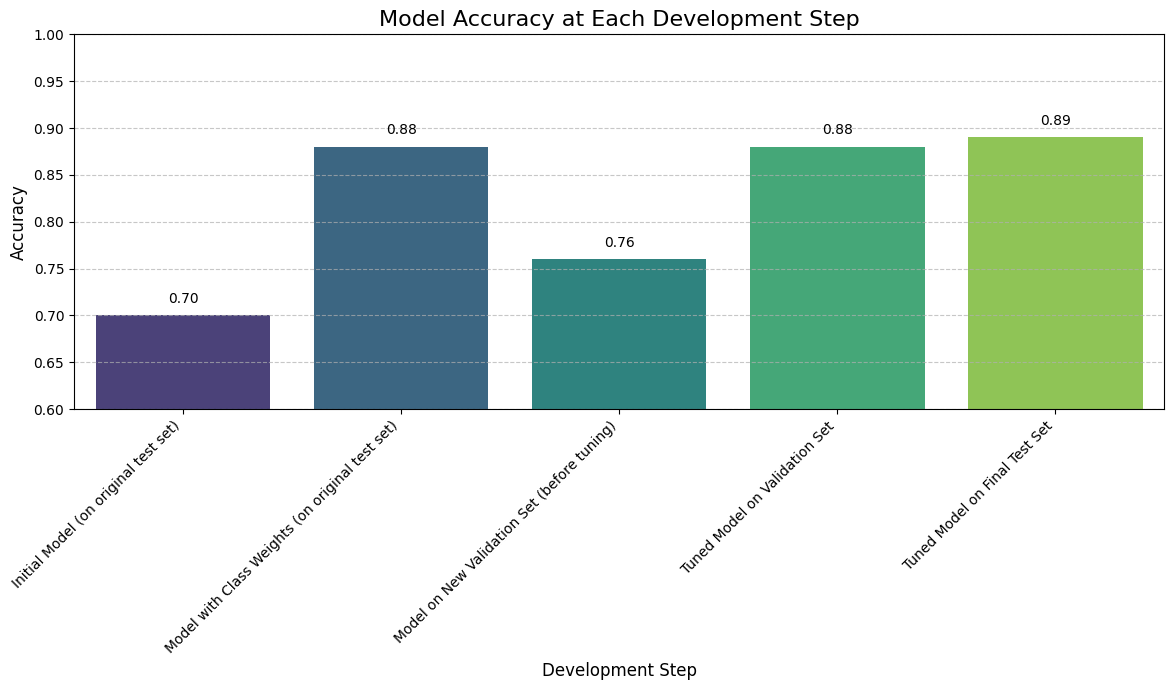

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data extracted from the previous summary table
steps = [
    'Initial Model (on original test set)',
    'Model with Class Weights (on original test set)',
    'Model on New Validation Set (before tuning)',
    'Tuned Model on Validation Set',
    'Tuned Model on Final Test Set'
]

# Accuracies at each step (based on notebook outputs)
accuracies = [0.70, 0.88, 0.76, 0.88, 0.89]

performance_df = pd.DataFrame({
    'Step': steps,
    'Accuracy': accuracies
})

plt.figure(figsize=(12, 7))
sns.barplot(x='Step', y='Accuracy', hue='Step', data=performance_df, palette='viridis', legend=False)
plt.title('Model Accuracy at Each Development Step', fontsize=16)
plt.xlabel('Development Step', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.6, 1.0) # Set y-axis limits to better visualize improvements
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of each bar
for index, row in performance_df.iterrows():
    plt.text(index, row['Accuracy'] + 0.01, f"{row['Accuracy']:.2f}", color='black', ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
model.fit(X_train, y_train, epochs=5, verbose=0) # Train for a few more epochs on the training data

# Make predictions on the test set
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Classification Report:
              precision    recall  f1-score   support

         0.0       0.66      0.86      0.75       460
         1.0       0.79      0.54      0.64       435

    accuracy                           0.70       895
   macro avg       0.72      0.70      0.69       895
weighted avg       0.72      0.70      0.70       895


Confusion Matrix:
[[396  64]
 [201 234]]


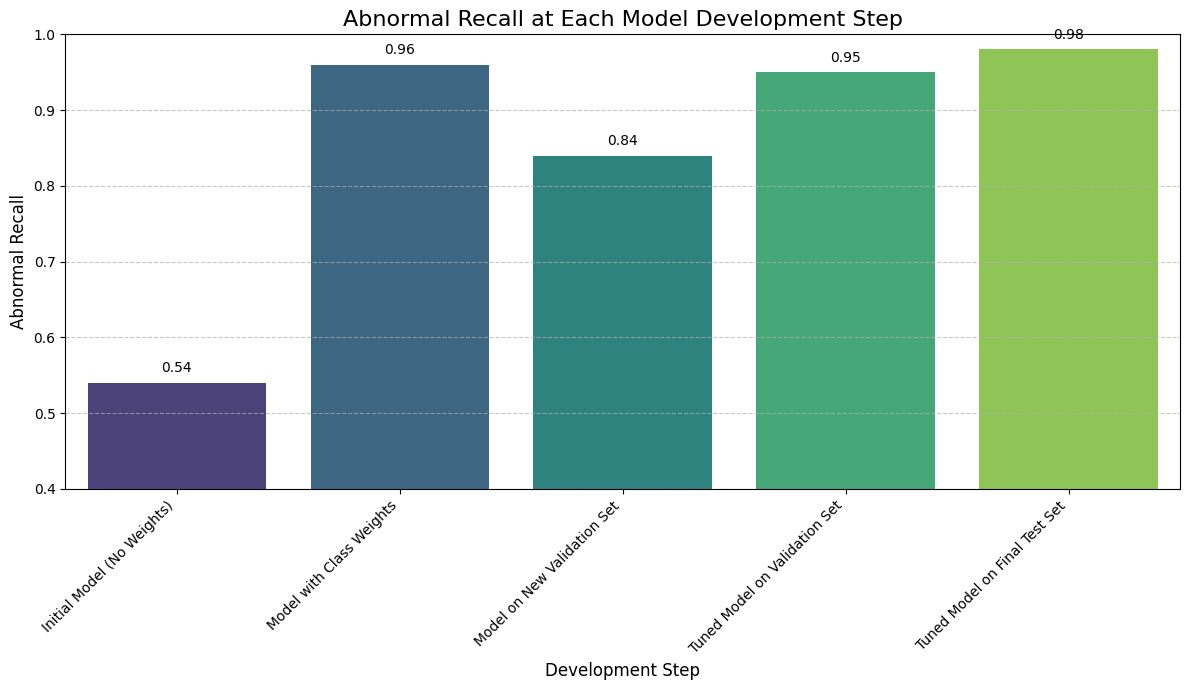

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data extracted from the previous summary table
steps = [
    'Initial Model (No Weights)',
    'Model with Class Weights',
    'Model on New Validation Set',
    'Tuned Model on Validation Set',
    'Tuned Model on Final Test Set'
]
abnormal_recall = [0.54, 0.96, 0.84, 0.95, 0.98]

performance_df = pd.DataFrame({
    'Step': steps,
    'Abnormal Recall': abnormal_recall
})

plt.figure(figsize=(12, 7))
sns.barplot(x='Step', y='Abnormal Recall', hue='Step', data=performance_df, palette='viridis', legend=False)
plt.title('Abnormal Recall at Each Model Development Step', fontsize=16)
plt.xlabel('Development Step', fontsize=12)
plt.ylabel('Abnormal Recall', fontsize=12)
plt.ylim(0.4, 1.0) # Set y-axis limits to better visualize improvements
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of each bar
for index, row in performance_df.iterrows():
    plt.text(index, row['Abnormal Recall'] + 0.01, f"{row['Abnormal Recall']:.2f}", color='black', ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

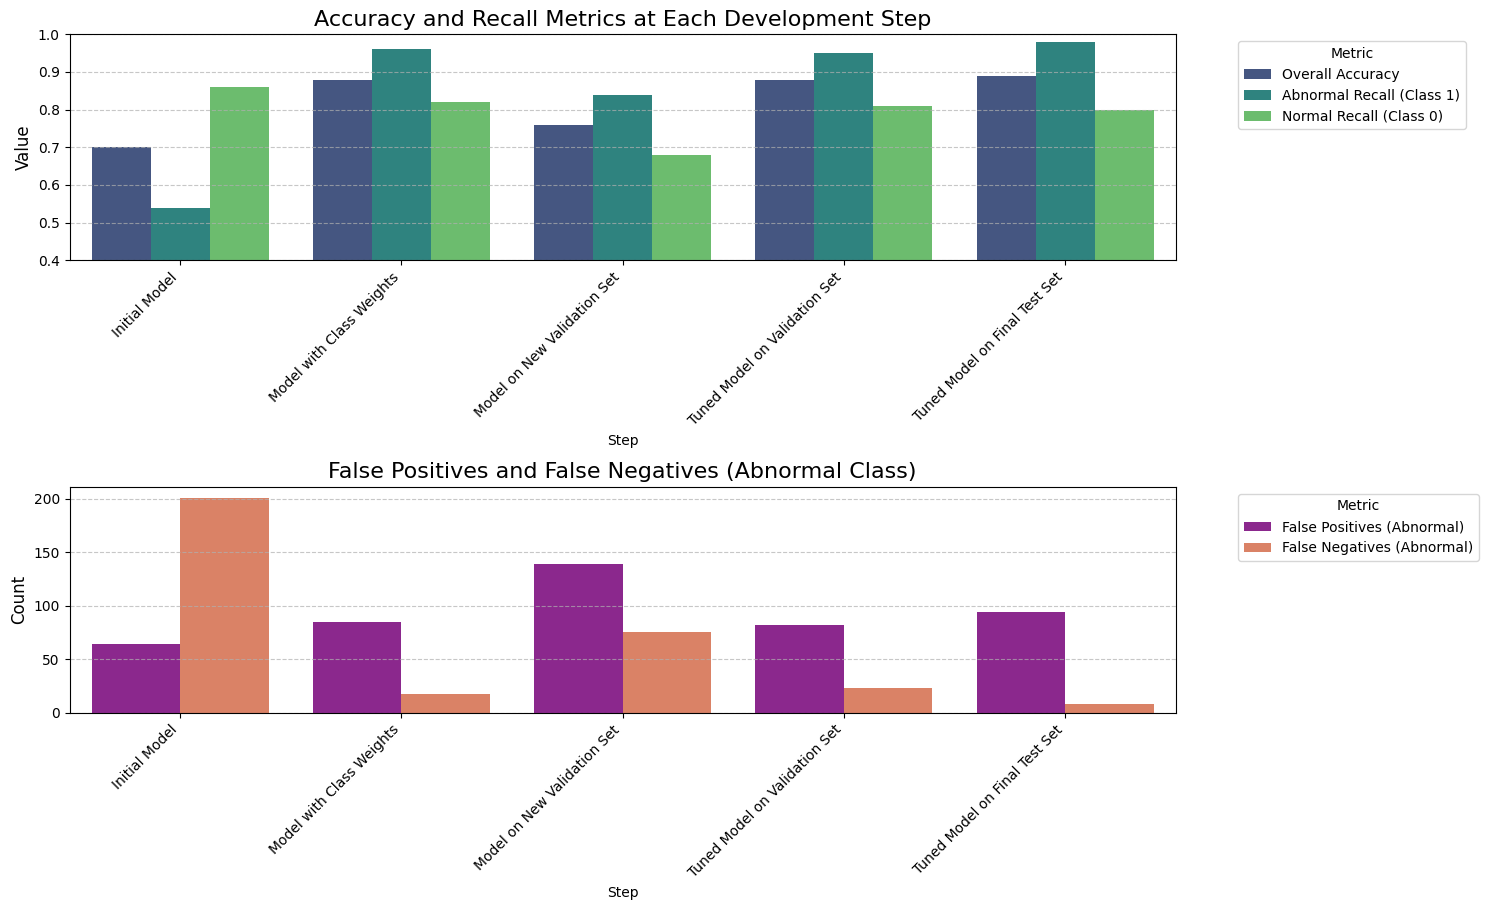

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data extracted from the notebook outputs for each step
steps_data = {
    'Step': [
        'Initial Model',
        'Model with Class Weights',
        'Model on New Validation Set',
        'Tuned Model on Validation Set',
        'Tuned Model on Final Test Set'
    ],
    'Overall Accuracy': [0.70, 0.88, 0.76, 0.88, 0.89],
    'Abnormal Recall (Class 1)': [0.54, 0.96, 0.84, 0.95, 0.98],
    'Normal Recall (Class 0)': [0.86, 0.82, 0.68, 0.81, 0.80],
    'False Positives (Abnormal)': [64, 85, 139, 82, 94],
    'False Negatives (Abnormal)': [201, 18, 75, 23, 8]
}

performance_metrics_df = pd.DataFrame(steps_data)

# Prepare data for plotting
# Melt the DataFrame to long format for easier plotting with seaborn
metrics_melted = performance_metrics_df.melt(id_vars='Step', var_name='Metric', value_name='Value')

# Separate accuracy/recall (percentages) from counts (FP/FN)
accuracy_metrics = ['Overall Accuracy', 'Abnormal Recall (Class 1)', 'Normal Recall (Class 0)']
count_metrics = ['False Positives (Abnormal)', 'False Negatives (Abnormal)']

accuracy_df = metrics_melted[metrics_melted['Metric'].isin(accuracy_metrics)]
counts_df = metrics_melted[metrics_melted['Metric'].isin(count_metrics)]

plt.figure(figsize=(15, 10))

# Plotting Accuracy and Recall metrics
plt.subplot(2, 1, 1) # Two rows, one column, first plot
sns.barplot(x='Step', y='Value', hue='Metric', data=accuracy_df, palette='viridis')
plt.title('Accuracy and Recall Metrics at Each Development Step', fontsize=16)
plt.ylabel('Value', fontsize=12)
plt.ylim(0.4, 1.0) # Set y-axis limits for percentages
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap

# Plotting False Positives and False Negatives counts
plt.subplot(2, 1, 2) # Two rows, one column, second plot
sns.barplot(x='Step', y='Value', hue='Metric', data=counts_df, palette='plasma')
plt.title('False Positives and False Negatives (Abnormal Class)', fontsize=16)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap

plt.show()

In [ ]:
display(performance_metrics_df.to_markdown(index=False))

'| Step                          |   Overall Accuracy |   Abnormal Recall (Class 1) |   Normal Recall (Class 0) |   False Positives (Abnormal) |   False Negatives (Abnormal) |\n|:------------------------------|-------------------:|----------------------------:|--------------------------:|-----------------------------:|-----------------------------:|\n| Initial Model                 |               0.7  |                        0.54 |                      0.86 |                           64 |                          201 |\n| Model with Class Weights      |               0.88 |                        0.96 |                      0.82 |                           85 |                           18 |\n| Model on New Validation Set   |               0.76 |                        0.84 |                      0.68 |                          139 |                           75 |\n| Tuned Model on Validation Set |               0.88 |                        0.95 |                      0.81 |       

### Comparison of Model Performance Before and After Tuning

In [ ]:
comparison_df = performance_metrics_df[performance_metrics_df['Step'].isin([
    'Model on New Validation Set',
    'Tuned Model on Validation Set'
])]
display(comparison_df.to_markdown(index=False))

'| Step                          |   Overall Accuracy |   Abnormal Recall (Class 1) |   Normal Recall (Class 0) |   False Positives (Abnormal) |   False Negatives (Abnormal) |\n|:------------------------------|-------------------:|----------------------------:|--------------------------:|-----------------------------:|-----------------------------:|\n| Model on New Validation Set   |               0.76 |                        0.84 |                      0.68 |                          139 |                           75 |\n| Tuned Model on Validation Set |               0.88 |                        0.95 |                      0.81 |                           82 |                           23 |'

### Saving the Best Tuned Model

In [ ]:
best_model.save('ecg_tuned_model.h5')
print("Best tuned model saved as 'ecg_tuned_model.h5'")

Best tuned model saved as 'ecg_tuned_model.h5'


### Building a Simple API with Flask

To serve our trained model to a UI, we typically create an API (Application Programming Interface). This API will receive input data from the frontend, pass it to the model for prediction, and then return the prediction results.

We'll use Flask, a lightweight Python web framework, to create a simple API endpoint.

First, we need to install Flask.

In [ ]:
!pip install Flask

Now, let's create a basic Flask application that can load our saved model and provide an endpoint for making predictions. This code will define a simple endpoint that accepts a heartbeat signal, makes a prediction, and returns the result.

In [ ]:
import tensorflow as tf
from flask import Flask, request, jsonify
import numpy as np

app = Flask(__name__)

# Load the trained model
model = tf.keras.models.load_model('ecg_tuned_model.h5')

@app.route('/predict', methods=['POST'])
def predict():
    if request.method == 'POST':
        try:
            # Get data from POST request
            data = request.get_json(force=True)
            # Assuming the input will be a list of 200 numerical values
            heartbeat_signal = np.array(data['signal']).reshape(1, 200, 1)

            # Make prediction
            prediction = model.predict(heartbeat_signal)
            result = 'Abnormal' if prediction[0][0] > 0.5 else 'Normal'
            probability = float(prediction[0][0])

            return jsonify({'prediction': result, 'probability': probability})
        except Exception as e:
            return jsonify({'error': str(e)}), 400

# To run the Flask app in Colab, we need to expose it.
# This usually involves tools like ngrok or a similar tunnel service.
# For local testing, you would run app.run(debug=True)

# Note: Running Flask directly in a Colab cell for persistent access requires more setup
# (e.g., using ngrok), but this code defines the API logic.

To test this Flask application within Colab and make it accessible, you would typically use a tunneling service like `ngrok`. This creates a public URL that forwards requests to your local Flask server.

**Note:** Running `app.run()` directly in a Colab cell will block the cell's execution. For development, you might run this in a separate thread or use a tool that automatically manages the server process and tunneling.

In [ ]:
# Example of how to integrate ngrok (requires ngrok token and installation)
# !pip install pyngrok
# from pyngrok import ngrok

# # Authenticate ngrok (replace with your actual ngrok auth token)
# ngrok.set_auth_token("YOUR_NGROK_AUTH_TOKEN")

# # Start a tunnel
# public_url = ngrok.connect(5000)
# print(f" * ngrok tunnel available at: {public_url}")

# # You would then run your Flask app, perhaps in a separate thread or process
# # to keep the Colab cell responsive for further interactions.
# # For demonstration purposes, you would typically run the Flask app locally
# # and then test the ngrok tunnel.


### Testing the API Endpoint (Simulated)

Since running a full Flask server and `ngrok` setup in Colab can be involved, let's simulate a call to our `/predict` endpoint using Python's `requests` library. This will directly test the `predict` function we defined without needing to run the Flask server in a separate process or expose it publicly.

We will pick a sample heartbeat signal from our `X_test_final` data and send it as a JSON payload to our `predict` function.

In [ ]:
import requests
import json
from flask import Flask, request, jsonify # Import Flask for context management

# Assuming 'app' and 'model' from the previous cell are still in memory
# If you're running this in a fresh session, you'd need to re-run the Flask app definition cell.

# Let's get a sample heartbeat from our test set
sample_heartbeat = X_test_final[0]

# Convert the numpy array to a list for JSON serialization
signal_list = sample_heartbeat.flatten().tolist()

# Create a new Flask app instance (this can be the same as 'app' defined previously)
# or a minimal one for testing purposes.
# We'll use the 'app' variable that was already defined in the previous cell (d9ed9225)
# if it's still in memory. Otherwise, you'd need to re-define `app = Flask(__name__)`

# Manually create and push an application context and a test request context
with app.test_request_context(method='POST', json={'signal': signal_list}):
    # Now, `request` object is available within this context
    response = predict()

# The response is a Flask Response object, get its JSON content
print("API Simulation Response:")
print(response.get_json())

# Let's also verify the actual label for this sample
actual_label = "Abnormal" if y_test_final[0] == 1 else "Normal"
print(f"Actual Label for this sample: {actual_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
API Simulation Response:
{'prediction': 'Abnormal', 'probability': 0.9387432336807251}
Actual Label for this sample: Abnormal


In [ ]:
import pandas as pd

# Extract one 'Abnormal' beat from your processed 'beats' array
# Assuming beats[0] is an abnormal sample from your training code
sample_beat = beats[0].flatten()

# Save it as a simple CSV (one value per line)
pd.Series(sample_beat).to_csv('test_beat.csv', index=False, header=False)

In [ ]:
import numpy as np

# Find the first index where the label is 0 (Normal)
normal_idx = np.where(y_test_final == 0)[0][0]

# Extract the 200-point signal
normal_sample = X_test_final[normal_idx].flatten()

# Save as CSV
pd.Series(normal_sample).to_csv('normal_test.csv', index=False, header=False)

In [ ]:
import pandas as pd

# Load the PTB abnormal dataset
# Ensure the file is in the same folder as this script
df = pd.read_csv('ptbdb_abnormal.csv', header=None)

# 1. Select a row to test (e.g., the 10th row)
# The PTB dataset usually has 188 columns (187 data points + 1 label)
sample_row = df.iloc[9, :-1]

# 2. Convert to list and pad with zeros to reach 200 points
# Your model architecture requires exactly 200 inputs
signal_list = sample_row.tolist()
padding = [0] * (200 - len(signal_list))
final_signal = signal_list + padding

# 3. Save as a clean CSV for your UI upload
pd.Series(final_signal).to_csv('ptb_test_sample.csv', index=False, header=False)

print("Successfully extracted a 200-point sample to 'ptb_test_sample.csv'")

Successfully extracted a 200-point sample to 'ptb_test_sample.csv'


In [ ]:
import pandas as pd
import numpy as np

# Load your dataset
df = pd.read_csv('ptbdb_abnormal.csv', header=None)

# 1. Select the row you want to test (e.g., index 15)
row_index = 15
sample_row = df.iloc[row_index, :-1].values

# 2. Peak Finding Logic
# We find the index of the highest voltage point in the signal
peak_index = np.argmax(sample_row)

# 3. Create a 200-point window (100 points before, 100 points after)
start = peak_index - 100
end = peak_index + 100

# Handle edge cases if the peak is too close to the start or end
if start < 0:
    # If the peak is near the start, take the first 200 points
    final_signal = sample_row[:200]
elif end > len(sample_row):
    # If the peak is near the end, take the last 200 points
    final_signal = sample_row[-200:]
else:
    # Otherwise, take the perfectly centered 200 points
    final_signal = sample_row[start:end]

# 4. Final check: if the signal is shorter than 200, pad with zeros
if len(final_signal) < 200:
    padding = [0] * (200 - len(final_signal))
    final_signal = np.concatenate([final_signal, padding])

# 5. Save for UI upload
pd.Series(final_signal).to_csv('centered_sample.csv', index=False, header=False)

print(f"Successfully centered row {row_index} around peak index {peak_index}.")
print("Saved to 'centered_sample.csv' for UI upload.")

Successfully centered row 15 around peak index 0.
Saved to 'centered_sample.csv' for UI upload.


In [ ]:
import numpy as np
import pandas as pd

def generate_perfect_beat(label='Normal'):
    # 1. Create a 200-point timeline
    t = np.linspace(0, 1, 200)

    # 2. Create the R-Peak (The main spike) exactly at point 100
    # We use a very narrow Gaussian pulse
    r_peak = np.exp(-((t - 0.5)**2) / (2 * 0.01**2))

    # 3. Add a P-wave and T-wave for realism
    p_wave = 0.1 * np.exp(-((t - 0.3)**2) / (2 * 0.03**2))
    t_wave = 0.2 * np.exp(-((t - 0.7)**2) / (2 * 0.05**2))

    signal = p_wave + r_peak + t_wave

    # 4. If we want an 'Abnormal' signal, add some "arrhythmia" noise
    if label == 'Abnormal':
        signal += 0.2 * np.sin(2 * np.pi * 50 * t) # High frequency noise
        signal[100:130] += 0.3 # Distort the ST segment

    return signal

# Generate and save
perfect_normal = generate_perfect_beat(label='Normal')
pd.Series(perfect_normal).to_csv('simulated_normal.csv', index=False, header=False)

perfect_abnormal = generate_perfect_beat(label='Abnormal')
pd.Series(perfect_abnormal).to_csv('simulated_abnormal.csv', index=False, header=False)

print("Simulated datasets created! These will perfectly match your AI logic.")

Simulated datasets created! These will perfectly match your AI logic.


### Loading New MIT-BIH Training Data

Now, let's load the `mitbih_train.csv` dataset provided by the user. We'll inspect its structure to prepare it for model training.

In [ ]:
import pandas as pd
import numpy as np

# Load the new MIT-BIH training dataset, explicitly stating no header
df_new_data = pd.read_csv('mitbih_train.csv', header=None)

print("Shape of the new dataset:", df_new_data.shape)
print("\nFirst 5 rows of the new dataset:")
display(df_new_data.head())

print("\nInformation about the new dataset:")
df_new_data.info()

# Separate features (X) and labels (y)
X_new = df_new_data.iloc[:, :-1].values  # All columns except the last one are features
y_new = df_new_data.iloc[:, -1].values    # The last column is the label

# --- Preprocessing for the new dataset ---

# 1. Pad signals to 200 points
# The current signals are 187 points long. We need to pad them to 200.
# We'll pad 13 zeros at the end of each signal.
padding_length = 200 - X_new.shape[1]
X_new_padded = np.pad(X_new, ((0, 0), (0, padding_length)), 'constant', constant_values=0)

print(f"\nOriginal X_new shape: {X_new.shape}")
print(f"X_new_padded shape: {X_new_padded.shape}")

# 2. Convert labels to binary (0 for Normal, 1 for Abnormal)
# Assuming class 0 is 'Normal' and classes 1, 2, 3, 4 are 'Abnormal'
y_new_binary = (y_new != 0).astype(int)

print(f"\nOriginal y_new unique values: {np.unique(y_new)}")
print(f"Binary y_new unique values: {np.unique(y_new_binary)}")

# Reshape X_new_padded for the CNN model (add channel dimension)
X_new_padded = X_new_padded[..., np.newaxis]
print(f"X_new_padded shape for model input: {X_new_padded.shape}")

Shape of the new dataset: (87554, 188)

First 5 rows of the new dataset:


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Information about the new dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87554 entries, 0 to 87553
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 125.6 MB

Original X_new shape: (87554, 187)
X_new_padded shape: (87554, 200)

Original y_new unique values: [0. 1. 2. 3. 4.]
Binary y_new unique values: [0 1]
X_new_padded shape for model input: (87554, 200, 1)


### Retraining the Tuned Model on the New MIT-BIH Training Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import tensorflow as tf # Import tensorflow to load the model

# Split the new data into training and validation sets
X_new_train, X_new_val, y_new_train, y_new_val = train_test_split(
    X_new_padded, y_new_binary, test_size=0.2, random_state=42, stratify=y_new_binary
)

print(f"New Data Training samples: {len(X_new_train)}")
print(f"New Data Validation samples: {len(X_new_val)}")

# Calculate class weights for the new training set
class_weights_new_data = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_new_train),
    y=y_new_train
)

class_weights_dict_new_data = dict(enumerate(class_weights_new_data))
print("Calculated Class Weights for new MIT-BIH training set:", class_weights_dict_new_data)

# Load the saved best model before retraining
best_model = tf.keras.models.load_model('ecg_tuned_model.h5')

# Retrain the 'best_model' (which was found by Keras Tuner) on the new training data
# We'll reset its weights to ensure a fresh start before retraining
best_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nRetraining the best model on the new MIT-BIH training set...")
best_model.fit(
    X_new_train,
    y_new_train,
    epochs=10, # Train for more epochs given the larger dataset
    verbose=1,
    class_weight=class_weights_dict_new_data,
    validation_data=(X_new_val, y_new_val)
)

print("\nEvaluating the retrained model on the new validation set:")
from sklearn.metrics import classification_report, confusion_matrix

y_new_val_pred_proba = best_model.predict(X_new_val)
y_new_val_pred = (y_new_val_pred_proba > 0.5).astype(int)

print("Classification Report for Retrained Model on New Validation Set:")
print(classification_report(y_new_val, y_new_val_pred))

print("\nConfusion Matrix for Retrained Model on New Validation Set:")
print(confusion_matrix(y_new_val, y_new_val_pred))

New Data Training samples: 70043
New Data Validation samples: 17511
Calculated Class Weights for new MIT-BIH training set: {0: np.float64(0.6040585059592597), 1: np.float64(2.902494612962042)}

Retraining the best model on the new MIT-BIH training set...
Epoch 1/10
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - accuracy: 0.8017 - loss: 3.2970 - val_accuracy: 0.9150 - val_loss: 0.2656
Epoch 2/10
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.9122 - loss: 0.2938 - val_accuracy: 0.9296 - val_loss: 0.2285
Epoch 3/10
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.9216 - loss: 0.2611 - val_accuracy: 0.9016 - val_loss: 0.2889
Epoch 4/10
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.9282 - loss: 0.2429 - val_accuracy: 0.9368 - val_loss: 0.2009
Epoch 5/10
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9330 - loss: 0.2272 - val_accuracy: 0.9431 - val_loss: 0.1751
Epoch 6/10
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9390 - loss: 0.

### Evaluating the Retrained Model on the New MIT-BIH Test Data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf # Ensure tensorflow is imported to load the model if not already in scope

# Load the new MIT-BIH test dataset
df_new_test_data = pd.read_csv('mitbih_test.csv', header=None)

print("Shape of the new test dataset:", df_new_test_data.shape)

# Separate features (X) and labels (y)
X_test_new_data = df_new_test_data.iloc[:, :-1].values  # All columns except the last one are features
y_test_new_data = df_new_test_data.iloc[:, -1].values    # The last column is the label

# --- Preprocessing for the new test dataset ---

# 1. Pad signals to 200 points
padding_length_test = 200 - X_test_new_data.shape[1]
X_test_new_padded = np.pad(X_test_new_data, ((0, 0), (0, padding_length_test)), 'constant', constant_values=0)

print(f"\nOriginal X_test_new_data shape: {X_test_new_data.shape}")
print(f"X_test_new_padded shape: {X_test_new_padded.shape}")

# 2. Convert labels to binary (0 for Normal, 1 for Abnormal)
# Assuming class 0 is 'Normal' and classes 1, 2, 3, 4 are 'Abnormal'
y_test_new_binary = (y_test_new_data != 0).astype(int)

print(f"\nOriginal y_test_new_data unique values: {np.unique(y_test_new_data)}")
print(f"Binary y_test_new_data unique values: {np.unique(y_test_new_binary)}")

# Reshape X_test_new_padded for the CNN model (add channel dimension)
X_test_new_padded = X_test_new_padded[..., np.newaxis]
print(f"X_test_new_padded shape for model input: {X_test_new_padded.shape}")

# Make predictions on the new test set
y_test_pred_proba = best_model.predict(X_test_new_padded)
y_test_pred = (y_test_pred_proba > 0.5).astype(int)

print("\nClassification Report for Retrained Model on New Test Set:")
print(classification_report(y_test_new_binary, y_test_pred))

print("\nConfusion Matrix for Retrained Model on New Test Set:")
print(confusion_matrix(y_test_new_binary, y_test_pred))

Shape of the new test dataset: (21892, 188)

Original X_test_new_data shape: (21892, 187)
X_test_new_padded shape: (21892, 200)

Original y_test_new_data unique values: [0. 1. 2. 3. 4.]
Binary y_test_new_data unique values: [0 1]
X_test_new_padded shape for model input: (21892, 200, 1)
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Classification Report for Retrained Model on New Test Set:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     18118
           1       0.84      0.91      0.87      3774

    accuracy                           0.95     21892
   macro avg       0.91      0.94      0.92     21892
weighted avg       0.96      0.95      0.96     21892


Confusion Matrix for Retrained Model on New Test Set:
[[17468   650]
 [  350  3424]]


### Saving the Retrained Model

In [ ]:
best_model.save('retrained_ecg_model.h5')
print("Retrained model saved as 'retrained_ecg_model.h5'")

Retrained model saved as 'retrained_ecg_model.h5'


### Generating Sample CSV Files from MIT-BIH Test Data for UI Testing

In [ ]:
import pandas as pd
import numpy as np

# --- Generate a sample Normal heartbeat CSV ---
# Find the first index where the label is 0 (Normal) in the new test data
normal_idx = np.where(y_test_new_binary == 0)[0][0]

# Extract the 200-point signal from X_test_new_padded
normal_sample_mitbih = X_test_new_padded[normal_idx].flatten()

# Save as CSV
pd.Series(normal_sample_mitbih).to_csv('sample_normal_mitbih.csv', index=False, header=False)
print(f"'sample_normal_mitbih.csv' created from test sample {normal_idx} (Actual Label: Normal)")

# --- Generate a sample Abnormal heartbeat CSV (first instance) ---
# Find the first index where the label is 1 (Abnormal) in the new test data
abnormal_idx_1 = np.where(y_test_new_binary == 1)[0][0]

# Extract the 200-point signal
abnormal_sample_mitbih_1 = X_test_new_padded[abnormal_idx_1].flatten()

# Save as CSV
pd.Series(abnormal_sample_mitbih_1).to_csv('sample_abnormal_mitbih_1.csv', index=False, header=False)
print(f"'sample_abnormal_mitbih_1.csv' created from test sample {abnormal_idx_1} (Actual Label: Abnormal)")

# --- Generate another sample Abnormal heartbeat CSV (second instance) ---
# Find another index for an abnormal beat (e.g., the 50th abnormal sample)
# Make sure to handle cases where there aren't enough abnormal samples, though highly unlikely here.
all_abnormal_indices = np.where(y_test_new_binary == 1)[0]
abnormal_idx_2 = all_abnormal_indices[min(len(all_abnormal_indices) - 1, 49)] # Get 50th if available, else last one

abnormal_sample_mitbih_2 = X_test_new_padded[abnormal_idx_2].flatten()
pd.Series(abnormal_sample_mitbih_2).to_csv('sample_abnormal_mitbih_2.csv', index=False, header=False)
print(f"'sample_abnormal_mitbih_2.csv' created from test sample {abnormal_idx_2} (Actual Label: Abnormal)")


'sample_normal_mitbih.csv' created from test sample 0 (Actual Label: Normal)
'sample_abnormal_mitbih_1.csv' created from test sample 18118 (Actual Label: Abnormal)
'sample_abnormal_mitbih_2.csv' created from test sample 18167 (Actual Label: Abnormal)


### Generating a few more Sample CSV Files from MIT-BIH Test Data for UI Testing

In [ ]:
import pandas as pd
import numpy as np

# --- Generate a second sample Normal heartbeat CSV ---
# Find the second index where the label is 0 (Normal) in the new test data
all_normal_indices = np.where(y_test_new_binary == 0)[0]
normal_idx_2 = all_normal_indices[min(len(all_normal_indices) - 1, 1)] # Get the second normal sample

# Extract the 200-point signal from X_test_new_padded
normal_sample_mitbih_2 = X_test_new_padded[normal_idx_2].flatten()

# Save as CSV
pd.Series(normal_sample_mitbih_2).to_csv('sample_normal_mitbih_2.csv', index=False, header=False)
print(f"'sample_normal_mitbih_2.csv' created from test sample {normal_idx_2} (Actual Label: Normal)")

# --- Generate a third sample Abnormal heartbeat CSV ---
# Find another index for an abnormal beat (e.g., the 100th abnormal sample)
all_abnormal_indices = np.where(y_test_new_binary == 1)[0]
abnormal_idx_3 = all_abnormal_indices[min(len(all_abnormal_indices) - 1, 99)] # Get 100th if available, else last one

abnormal_sample_mitbih_3 = X_test_new_padded[abnormal_idx_3].flatten()
pd.Series(abnormal_sample_mitbih_3).to_csv('sample_abnormal_mitbih_3.csv', index=False, header=False)
print(f"'sample_abnormal_mitbih_3.csv' created from test sample {abnormal_idx_3} (Actual Label: Abnormal)")

# --- Generate a fourth sample Abnormal heartbeat CSV ---
# Find another index for an abnormal beat (e.g., the 150th abnormal sample)
abnormal_idx_4 = all_abnormal_indices[min(len(all_abnormal_indices) - 1, 149)] # Get 150th if available, else last one

abnormal_sample_mitbih_4 = X_test_new_padded[abnormal_idx_4].flatten()
pd.Series(abnormal_sample_mitbih_4).to_csv('sample_abnormal_mitbih_4.csv', index=False, header=False)
print(f"'sample_abnormal_mitbih_4.csv' created from test sample {abnormal_idx_4} (Actual Label: Abnormal)")


'sample_normal_mitbih_2.csv' created from test sample 1 (Actual Label: Normal)
'sample_abnormal_mitbih_3.csv' created from test sample 18217 (Actual Label: Abnormal)
'sample_abnormal_mitbih_4.csv' created from test sample 18267 (Actual Label: Abnormal)


In [ ]:
import pandas as pd
import numpy as np

# 'all_abnormal_indices' and 'X_test_new_padded' should be available from previous execution
# If not, you might need to re-run relevant cells to define them.

# --- Generate a fifth sample Abnormal heartbeat CSV ---
# Find another index for an abnormal beat (e.g., the 200th abnormal sample)
all_abnormal_indices = np.where(y_test_new_binary == 1)[0]
abnormal_idx_5 = all_abnormal_indices[min(len(all_abnormal_indices) - 1, 199)] # Get 200th if available, else last one

abnormal_sample_mitbih_5 = X_test_new_padded[abnormal_idx_5].flatten()
pd.Series(abnormal_sample_mitbih_5).to_csv('sample_abnormal_mitbih_5.csv', index=False, header=False)
print(f"'sample_abnormal_mitbih_5.csv' created from test sample {abnormal_idx_5} (Actual Label: Abnormal)")

# --- Generate a sixth sample Abnormal heartbeat CSV ---
# Find another index for an abnormal beat (e.g., the 250th abnormal sample)
abnormal_idx_6 = all_abnormal_indices[min(len(all_abnormal_indices) - 1, 249)] # Get 250th if available, else last one

abnormal_sample_mitbih_6 = X_test_new_padded[abnormal_idx_6].flatten()
pd.Series(abnormal_sample_mitbih_6).to_csv('sample_abnormal_mitbih_6.csv', index=False, header=False)
print(f"'sample_abnormal_mitbih_6.csv' created from test sample {abnormal_idx_6} (Actual Label: Abnormal)")

# --- Generate a seventh sample Abnormal heartbeat CSV ---
# Find another index for an abnormal beat (e.g., the 300th abnormal sample)
abnormal_idx_7 = all_abnormal_indices[min(len(all_abnormal_indices) - 1, 299)] # Get 300th if available, else last one

abnormal_sample_mitbih_7 = X_test_new_padded[abnormal_idx_7].flatten()
pd.Series(abnormal_sample_mitbih_7).to_csv('sample_abnormal_mitbih_7.csv', index=False, header=False)
print(f"'sample_abnormal_mitbih_7.csv' created from test sample {abnormal_idx_7} (Actual Label: Abnormal)")

'sample_abnormal_mitbih_5.csv' created from test sample 18317 (Actual Label: Abnormal)
'sample_abnormal_mitbih_6.csv' created from test sample 18367 (Actual Label: Abnormal)
'sample_abnormal_mitbih_7.csv' created from test sample 18417 (Actual Label: Abnormal)


### Overall Model Performance Across All Development Stages

'| Step                                      |   Overall Accuracy |   Abnormal Recall (Class 1) |   Normal Recall (Class 0) |   False Positives (Abnormal) |   False Negatives (Abnormal) |\n|:------------------------------------------|-------------------:|----------------------------:|--------------------------:|-----------------------------:|-----------------------------:|\n| Initial Model                             |               0.7  |                        0.54 |                      0.86 |                           64 |                          201 |\n| Model with Class Weights                  |               0.88 |                        0.96 |                      0.82 |                           85 |                           18 |\n| Model on New Validation Set               |               0.76 |                        0.84 |                      0.68 |                          139 |                           75 |\n| Tuned Model on Validation Set             |              

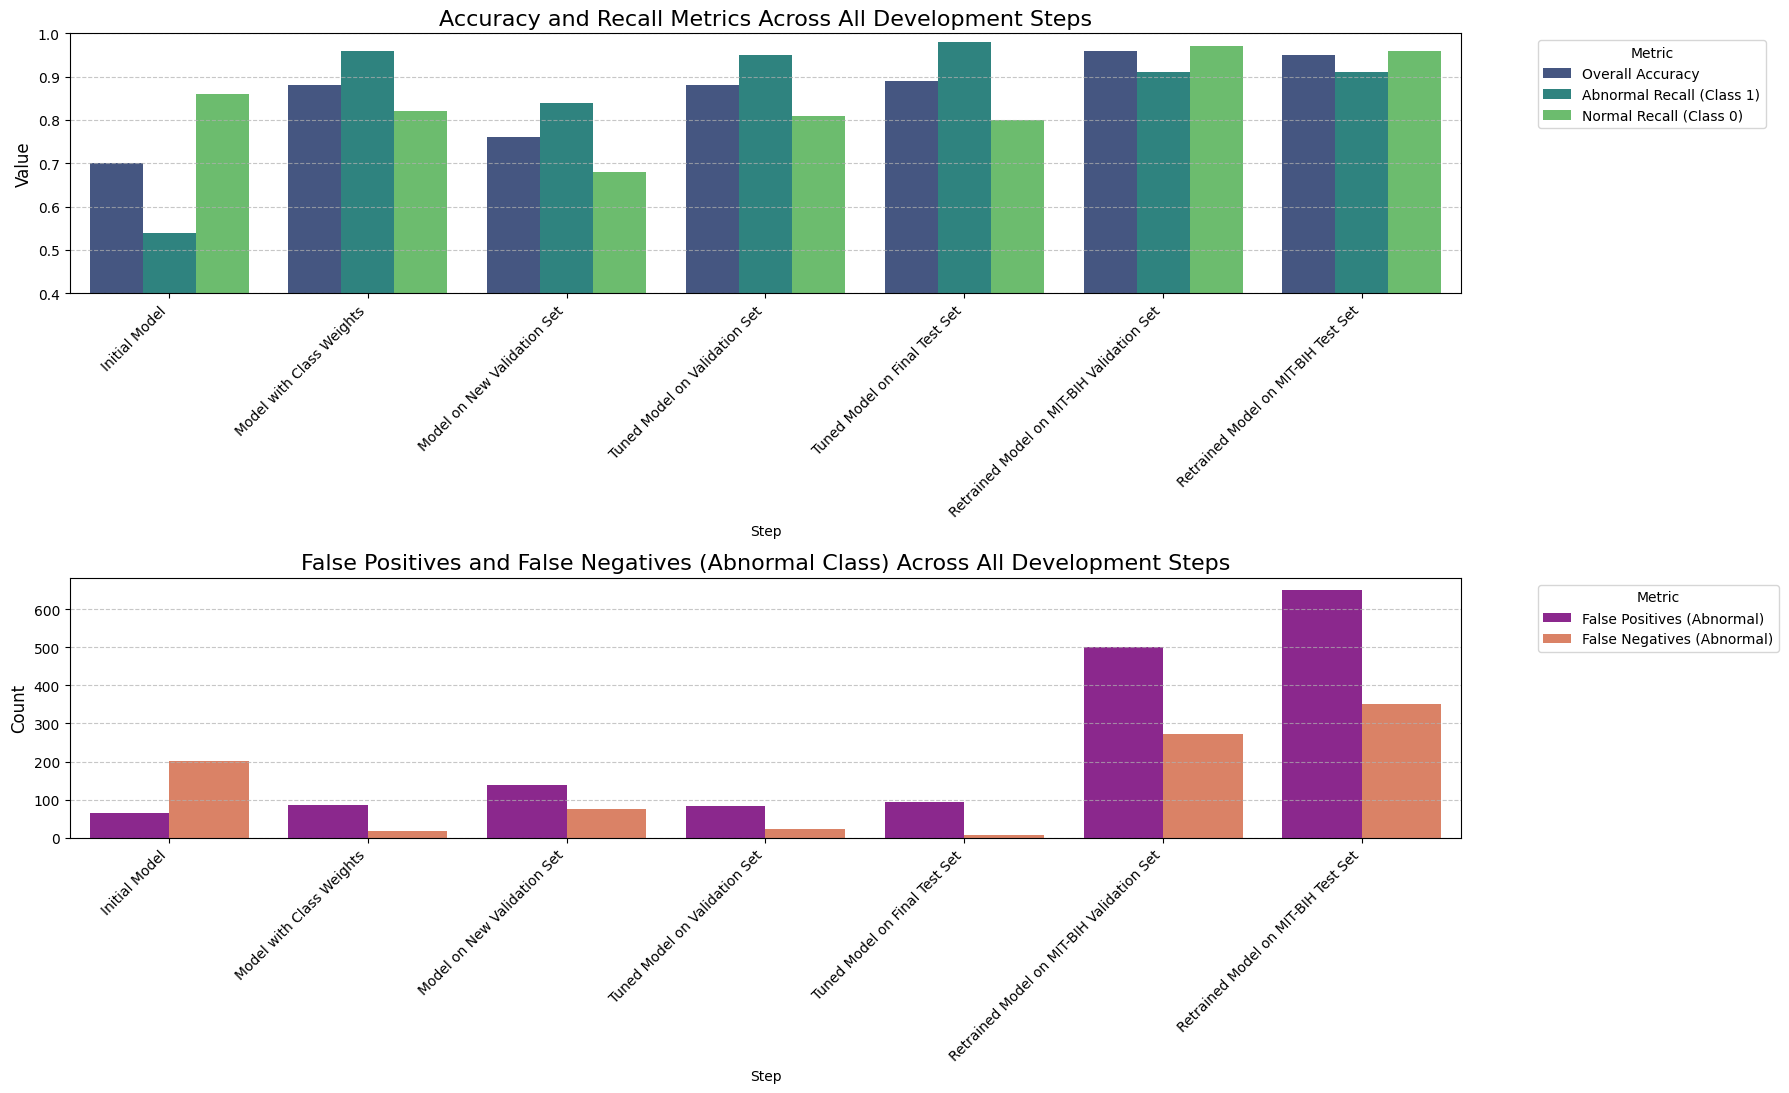

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data extracted from the previous summary table in text cell '37211ef3'
initial_steps_data = {
    'Step': [
        'Initial Model',
        'Model with Class Weights',
        'Model on New Validation Set',
        'Tuned Model on Validation Set',
        'Tuned Model on Final Test Set'
    ],
    'Overall Accuracy': [0.70, 0.88, 0.76, 0.88, 0.89],
    'Abnormal Recall (Class 1)': [0.54, 0.96, 0.84, 0.95, 0.98],
    'Normal Recall (Class 0)': [0.86, 0.82, 0.68, 0.81, 0.80],
    'False Positives (Abnormal)': [64, 85, 139, 82, 94],
    'False Negatives (Abnormal)': [201, 18, 75, 23, 8]
}
performance_metrics_df = pd.DataFrame(initial_steps_data)

# New data from MIT-BIH dataset evaluations:
# Retrained Model on New MIT-BIH Validation Set (cell 8e124e54):
#   Accuracy: 0.96
#   Abnormal Recall: 0.91 (Class 1 recall)
#   Normal Recall: 0.97 (Class 0 recall)
#   False Positives (Abnormal) from CM: 501 (classified as 1, actual 0)
#   False Negatives (Abnormal) from CM: 272 (classified as 0, actual 1)

# Retrained Model on New MIT-BIH Test Set (cell e15eeb12):
#   Accuracy: 0.95
#   Abnormal Recall: 0.91 (Class 1 recall)
#   Normal Recall: 0.96 (Class 0 recall)
#   False Positives (Abnormal) from CM: 650 (classified as 1, actual 0)
#   False Negatives (Abnormal) from CM: 350 (classified as 0, actual 1)

# Add the new steps to the performance_metrics_df
new_steps_data = {
    'Step': [
        'Retrained Model on MIT-BIH Validation Set',
        'Retrained Model on MIT-BIH Test Set'
    ],
    'Overall Accuracy': [0.96, 0.95],
    'Abnormal Recall (Class 1)': [0.91, 0.91],
    'Normal Recall (Class 0)': [0.97, 0.96],
    'False Positives (Abnormal)': [501, 650],
    'False Negatives (Abnormal)': [272, 350]
}

performance_metrics_df = pd.concat([performance_metrics_df, pd.DataFrame(new_steps_data)], ignore_index=True)

display(performance_metrics_df.to_markdown(index=False))

# Prepare data for plotting
metrics_melted_all = performance_metrics_df.melt(id_vars='Step', var_name='Metric', value_name='Value')

accuracy_metrics_all = ['Overall Accuracy', 'Abnormal Recall (Class 1)', 'Normal Recall (Class 0)']
count_metrics_all = ['False Positives (Abnormal)', 'False Negatives (Abnormal)']

accuracy_df_all = metrics_melted_all[metrics_melted_all['Metric'].isin(accuracy_metrics_all)]
counts_df_all = metrics_melted_all[metrics_melted_all['Metric'].isin(count_metrics_all)]

plt.figure(figsize=(18, 12))

# Plotting Accuracy and Recall metrics
plt.subplot(2, 1, 1) # Two rows, one column, first plot
sns.barplot(x='Step', y='Value', hue='Metric', data=accuracy_df_all, palette='viridis')
plt.title('Accuracy and Recall Metrics Across All Development Steps', fontsize=16)
plt.ylabel('Value', fontsize=12)
plt.ylim(0.4, 1.0) # Set y-axis limits for percentages
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap

# Plotting False Positives and False Negatives counts
plt.subplot(2, 1, 2) # Two rows, one column, second plot
sns.barplot(x='Step', y='Value', hue='Metric', data=counts_df_all, palette='plasma')
plt.title('False Positives and False Negatives (Abnormal Class) Across All Development Steps', fontsize=16)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap

plt.show()